In [16]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt  

In [ ]:
heights = [None] * 4  # Participant demographics removed for confidentiality
weights = [None] * 4
ages = [None] * 4
genders = [None] * 4

person1_df = [night1, night2, night3, night4, night5, night6, night7, night8, night9, night10, night11, night12, night13, night14]
person2_df=[night15, night16, night17, night18, night19, night20, night21, night22, night23]
person3_df=[night24, night25, night26,night27,night28,night29,night30,night31,night32, night33,night34,night35,night36,night37]
person4_df=[night38,night39,night40,night41,night42,night43,night44,night45]

for df in person1_df:
    for i in range(len(df)):
        df.at[i, 'Height'] = heights[0]
        df.at[i, 'Weight'] = weights[0]
        df.at[i, 'Age'] = ages[0]
        df.at[i, 'Gender'] = genders[0]

for df in person2_df:
    for i in range(len(df)):
        df.at[i, 'Height'] = heights[1]
        df.at[i, 'Weight'] = weights[1]
        df.at[i, 'Age'] = ages[1]
        df.at[i, 'Gender'] = genders[1]

for df in person3_df:
    for i in range(len(df)):
        df.at[i, 'Height'] = heights[2]
        df.at[i, 'Weight'] = weights[2]
        df.at[i, 'Age'] = ages[2]
        df.at[i, 'Gender'] = genders[2]

for df in person4_df:
    for i in range(len(df)):
        df.at[i, 'Height'] = heights[3]
        df.at[i, 'Weight'] = weights[3]
        df.at[i, 'Age'] = ages[3]
        df.at[i, 'Gender'] = genders[3]


In [19]:
# Select features: HRV + Infrared/Red Ratio + Demographics
features = ['rmssd', 'hf', 'lf', 'Infrared to Red Signal Ratio', 'Height', 'Weight', 'Age', 'Gender']
target = 'glucose'

# Combine all nights into a single dataset
all_nights_df = pd.concat(night_dfs, axis=0)

# Apply One-Hot Encoding to Gender
gender_encoded = pd.get_dummies(all_nights_df['Gender'], prefix='Gender', drop_first=True)

# Drop original gender column and merge encoded columns
all_nights_df = all_nights_df.drop(columns=['Gender'])
all_nights_df = pd.concat([all_nights_df, gender_encoded], axis=1)
all_nights_df = all_nights_df.dropna(subset=['glucose'])


# Extract updated feature names
updated_features = [col for col in all_nights_df.columns if col not in [target, 'timestamp']]

# Extract input features (X) and target variable (y)
X = all_nights_df[updated_features].values
y = all_nights_df[target].values

In [20]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [21]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


In [22]:
print(X_train.shape)

(3143, 8)


In [23]:

# Initialize and train model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

LinearRegression()

In [24]:
# Get number of parameters
num_params = lr_model.coef_.size + 1  # Coefficients + bias

# Estimate model size in MB (assuming FP32, 4 bytes per parameter)
model_size_mb = (num_params * 4) / (1024 ** 2)
print(f"Linear Regression Model Size: {model_size_mb:.6f} MB")

Linear Regression Model Size: 0.000034 MB


In [26]:
print(f"Training data shape: {X_train.shape}")


Training data shape: (3143, 8)


In [28]:
import time
# Example input for prediction (batch size of 8, each with 8 features)
sample_input = np.random.rand(8, 8)  # 8 samples, 8 features each

# Measure inference time for Linear Regression
start_time = time.time()
predictions = lr_model.predict(sample_input)
total_inference_time = time.time() - start_time  # Total time in seconds

# Calculate time per sample (in milliseconds)
time_per_sample = (total_inference_time / sample_input.shape[0]) * 1000  # Convert to milliseconds

print(f"Total Inference Time: {total_inference_time:.6f} seconds")
print(f"Time Per Sample: {time_per_sample:.6f} ms")

Total Inference Time: 0.005714 seconds
Time Per Sample: 0.714242 ms


In [9]:
# Predict glucose values
y_pred = lr_model.predict(X_test)

# Compute evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print results
print("\nLinear Regression Model Performance:")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R² Score: {r2:.4f}")


Linear Regression Model Performance:
Mean Absolute Error (MAE): 0.5249
Mean Squared Error (MSE): 0.5348
R² Score: 0.1321


In [10]:
# Get model coefficients
coefficients = lr_model.coef_

# Create a DataFrame to display feature importance
feature_importance = pd.DataFrame({'Feature': features, 'Coefficient': coefficients})
feature_importance = feature_importance.sort_values(by='Coefficient', ascending=False)

print("\nFeature Importance (Linear Regression Coefficients):")
print(feature_importance)


Feature Importance (Linear Regression Coefficients):
                        Feature  Coefficient
7                        Gender     0.131815
2                            lf     0.024149
1                            hf    -0.004625
3  Infrared to Red Signal Ratio    -0.028654
0                         rmssd    -0.050339
4                        Height    -0.054039
5                        Weight    -0.268409
6                           Age    -0.368015


(<module 'matplotlib.pyplot' from '/Users/tomliu/Library/Python/3.11/lib/python/site-packages/matplotlib/pyplot.py'>,
 [681, 73, 0, 32, 0])

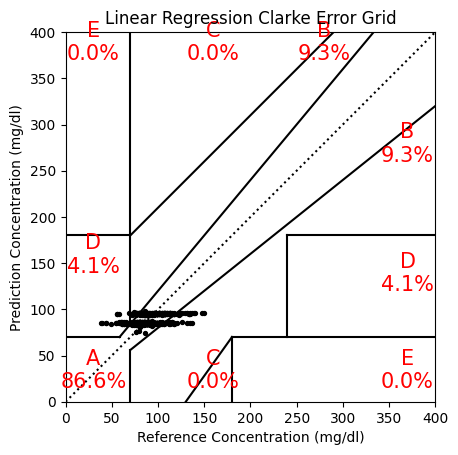

In [ ]:
def clarke_error_grid(ref_values, pred_values, title_string):
    ref_values = np.array(ref_values) * 18
    pred_values = np.array(pred_values) * 18
    total_points = len(ref_values)  # Total number of points

    # Set up plot
    plt.scatter(ref_values, pred_values, marker='o', color='black', s=8)
    plt.title(title_string + " Clarke Error Grid")
    plt.xlabel("Reference Concentration (mg/dl)")
    plt.ylabel("Prediction Concentration (mg/dl)")
    plt.xticks([0, 50, 100, 150, 200, 250, 300, 350, 400])
    plt.yticks([0, 50, 100, 150, 200, 250, 300, 350, 400])
    plt.gca().set_facecolor('white')

    # Set axes lengths
    plt.gca().set_xlim([0, 400])
    plt.gca().set_ylim([0, 400])
    plt.gca().set_aspect((400)/(400))

    # Plot zone lines
    plt.plot([0, 400], [0, 400], ':', c='black')                      # Theoretical 45 regression line
    plt.plot([0, 175/3], [70, 70], '-', c='black')
    plt.plot([175/3, 400/1.2], [70, 400], '-', c='black')           
    plt.plot([70, 70], [84, 400],'-', c='black')
    plt.plot([0, 70], [180, 180], '-', c='black')
    plt.plot([70, 290], [180, 400], '-', c='black')
    plt.plot([70, 70], [0, 56], '-', c='black')                    
    plt.plot([70, 400], [56, 320],'-', c='black')
    plt.plot([180, 180], [0, 70], '-', c='black')
    plt.plot([180, 400], [70, 70], '-', c='black')
    plt.plot([240, 240], [70, 180],'-', c='black')
    plt.plot([240, 400], [180, 180], '-', c='black')
    plt.plot([130, 180], [0, 70], '-', c='black')

    # Statistics from the data
    zone = [0] * 5  # [A, B, C, D, E]
    for i in range(len(ref_values)):
        if (ref_values[i] <= 70 and pred_values[i] <= 70) or (pred_values[i] <= 1.2 * ref_values[i] and pred_values[i] >= 0.8 * ref_values[i]):
            zone[0] += 1  # Zone A

        elif (ref_values[i] >= 180 and pred_values[i] <= 70) or (ref_values[i] <= 70 and pred_values[i] >= 180):
            zone[4] += 1  # Zone E

        elif ((ref_values[i] >= 70 and ref_values[i] <= 290) and pred_values[i] >= ref_values[i] + 110) or ((ref_values[i] >= 130 and ref_values[i] <= 180) and (pred_values[i] <= (7/5) * ref_values[i] - 182)):
            zone[2] += 1  # Zone C

        elif (ref_values[i] >= 240 and (pred_values[i] >= 70 and pred_values[i] <= 180)) or (ref_values[i] <= 175/3 and pred_values[i] <= 180 and pred_values[i] >= 70) or ((ref_values[i] >= 175/3 and ref_values[i] <= 70) and pred_values[i] >= (6/5) * ref_values[i]):
            zone[3] += 1  # Zone D

        else:
            zone[1] += 1  # Zone B

    # Convert counts to percentages
    zone_percentages = [100 * (z / total_points) for z in zone]

    # Add zone labels with percentage in red
    plt.text(30, 15, f"A\n{zone_percentages[0]:.1f}%", fontsize=15, color='red', ha='center')
    plt.text(370, 260, f"B\n{zone_percentages[1]:.1f}%", fontsize=15, color='red', ha='center')
    plt.text(280, 370, f"B\n{zone_percentages[1]:.1f}%", fontsize=15, color='red', ha='center')
    plt.text(160, 370, f"C\n{zone_percentages[2]:.1f}%", fontsize=15, color='red', ha='center')
    plt.text(160, 15, f"C\n{zone_percentages[2]:.1f}%", fontsize=15, color='red', ha='center')
    plt.text(30, 140, f"D\n{zone_percentages[3]:.1f}%", fontsize=15, color='red', ha='center')
    plt.text(370, 120, f"D\n{zone_percentages[3]:.1f}%", fontsize=15, color='red', ha='center')
    plt.text(30, 370, f"E\n{zone_percentages[4]:.1f}%", fontsize=15, color='red', ha='center')
    plt.text(370, 15, f"E\n{zone_percentages[4]:.1f}%", fontsize=15, color='red', ha='center')

    return plt, zone

# Example usage
clarke_error_grid(y_test, y_pred, "Linear Regression")